# Análisis Exploratorio de Datos (EDA)
## Dataset: Messy Clinic Appointments

**Asignatura:** SCY1101 - Programación para la Ciencia de Datos  
**Objetivo:** Explorar el dataset crudo, identificar problemas de calidad de datos y definir
las decisiones de transformación que luego implementaremos en el Pipeline.

**Variable objetivo:** `follow_up_required` → predecir si un paciente necesita seguimiento.

---

### Diccionario de Variables

| Columna | Tipo | Descripción |
|---|---|---|
| `patient_id` | int | Identificador del paciente (no único por fila) |
| `patient_name` | str | Nombre del paciente |
| `age` | int | Edad del paciente |
| `gender` | str | Género (con múltiples representaciones) |
| `appointment_date` | str | Fecha de la cita (múltiples formatos) |
| `booking_date` | str | Fecha en que se agendó la cita |
| `doctor` | str | Nombre del médico |
| `department` | str | Departamento clínico |
| `billing_amount` | str | Monto cobrado (con símbolos de moneda) |
| `follow_up_required` | str | **Variable objetivo** (múltiples representaciones de Sí/No) |


## 0. Configuración del entorno

In [1]:
import sys
import os
sys.path.append('..')  # Para importar desde src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Rutas
from src.config import RAW_CSV, OUTPUTS_DIR
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f" Entorno configurado correctamente.")
print(f"   Dataset: {RAW_CSV}")
print(f"   Outputs: {OUTPUTS_DIR}")


 Entorno configurado correctamente.
   Dataset: c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\data\raw\messy_clinic_appointments.csv
   Outputs: c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\outputs


## 1. Verificación de Integridad (Auditoría SHA-256)

Antes de explorar cualquier dato, verificamos que el archivo no fue modificado
desde que lo recibimos. Usamos el hash SHA-256 almacenado en `metadata.json`.

Si el hash cambia → alguien modificó el CSV sin autorización o se corrompió.


In [2]:
from src.audit import create_metadata_file, verify_data_integrity
from src.config import METADATA_JSON

# Creamos el metadata.json si no existe (solo se ejecuta una vez)
if not os.path.exists(METADATA_JSON):
    print("Primera ejecución: generando metadata.json...")
    create_metadata_file(str(RAW_CSV), str(METADATA_JSON))

# Verificamos integridad
integrity_ok = verify_data_integrity(str(RAW_CSV), str(METADATA_JSON))
assert integrity_ok, "ALERTA: La integridad del dataset está comprometida."


INFO: Verificando integridad de: messy_clinic_appointments.csv
INFO: Integridad verificada. El dataset no ha sido modificado.


## 2. Carga y Vista General del Dataset

In [3]:
df = pd.read_csv(RAW_CSV)

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(8)


Dimensiones: 1000 filas × 10 columnas


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2026/02/26,2024/12/03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,05/23/2025,12-Jun-2024,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-2025,"August 05, 24",Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,"May 18, 25",09/09/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,"September 26, 25",08/31/2025,Kimberly Fields,General,NaN,Yes
6,1018,Alexander Harris,22,Female,30-Oct-2025,12/29/2024,Jim Jones,Cardiology,€99.0,No
7,1074,Raymond Williams,57,M,2025/04/23,28-Mar-2025,James Brooks,Neurology,Rs374.63,No


In [4]:
# Resumen de tipos de datos y valores no nulos
print("=== Información general ===")
df.info()


=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          1000 non-null   int64
 1   patient_name        1000 non-null   str  
 2   age                 1000 non-null   int64
 3   gender              950 non-null    str  
 4   appointment_date    1000 non-null   str  
 5   booking_date        1000 non-null   str  
 6   doctor              1000 non-null   str  
 7   department          1000 non-null   str  
 8   billing_amount      950 non-null    str  
 9   follow_up_required  1000 non-null   str  
dtypes: int64(2), str(8)
memory usage: 78.3 KB


In [5]:
# Estadísticas descriptivas de columnas numéricas
df.describe().round(2)


,patient_id,age
count,1000.00,1000.00
mean,1050.52,53.75
std,28.89,21.14
min,1000.00,18.00
25%,1025.00,34.00
50%,1051.00,55.00
75%,1075.00,71.00
max,1100.00,90.00


## 3. Análisis de Valores Nulos

El dataset usa `NaN` real en algunas columnas, pero también representa datos
faltantes con otros encodings (ver sección 4). Aquí vemos solo los nulos reales.


                    Nulos  % Nulos
billing_amount         50      5.0
gender                 50      5.0
patient_name            0      0.0
patient_id              0      0.0
appointment_date        0      0.0
age                     0      0.0
booking_date            0      0.0
doctor                  0      0.0
department              0      0.0
follow_up_required      0      0.0


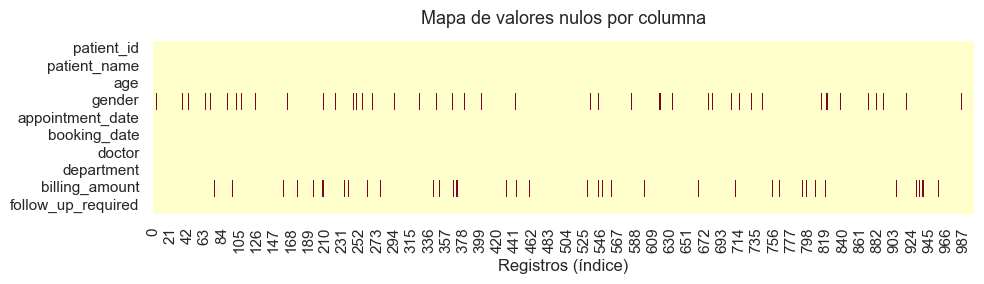

Gráfico guardado en outputs/


In [6]:
nulos = df.isnull().sum()
pct_nulos = (df.isnull().mean() * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': pct_nulos
}).sort_values('% Nulos', ascending=False)

print(resumen_nulos)

# ── Mapa de calor de nulos
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    df.isnull().T,
    cmap='YlOrRd',
    cbar=False,
    ax=ax,
    yticklabels=df.columns
)
ax.set_title('Mapa de valores nulos por columna', fontsize=13, pad=12)
ax.set_xlabel('Registros (índice)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'nulos_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado en outputs/")


## 4. Variable Objetivo: `follow_up_required`

### Problema detectado
La variable objetivo tiene **6 representaciones distintas** para solo 2 significados:
- Positivo (necesita seguimiento): `Yes`, `Y`, `1`
- Negativo (no necesita): `No`, `N`, `0`

Esto es típico de datos reales donde distintos operadores ingresaron la información
de formas diferentes. **Debe normalizarse antes de cualquier análisis.**


In [7]:
# Ver todas las variantes tal como están en el CSV
print("Variantes encontradas en follow_up_required:")
print(df['follow_up_required'].value_counts(dropna=False))


Variantes encontradas en follow_up_required:
follow_up_required
0      185
Y      182
Yes    181
N      154
1      151
No     147
Name: count, dtype: int64


In [8]:
# Función de normalización
def normalize_follow_up(x):
    """Convierte las 6 variantes de follow_up_required a binario 1/0."""
    x = str(x).strip().lower()
    if x in ['yes', 'y', '1']:
        return 1
    elif x in ['no', 'n', '0']:
        return 0
    return np.nan  # Si hubiera un valor inesperado

df['follow_up_bin'] = df['follow_up_required'].apply(normalize_follow_up)

print("Después de normalizar:")
print(df['follow_up_bin'].value_counts(dropna=False))
print(f"\nNulos generados por normalización: {df['follow_up_bin'].isna().sum()}")


Después de normalizar:
follow_up_bin
1    514
0    486
Name: count, dtype: int64

Nulos generados por normalización: 0


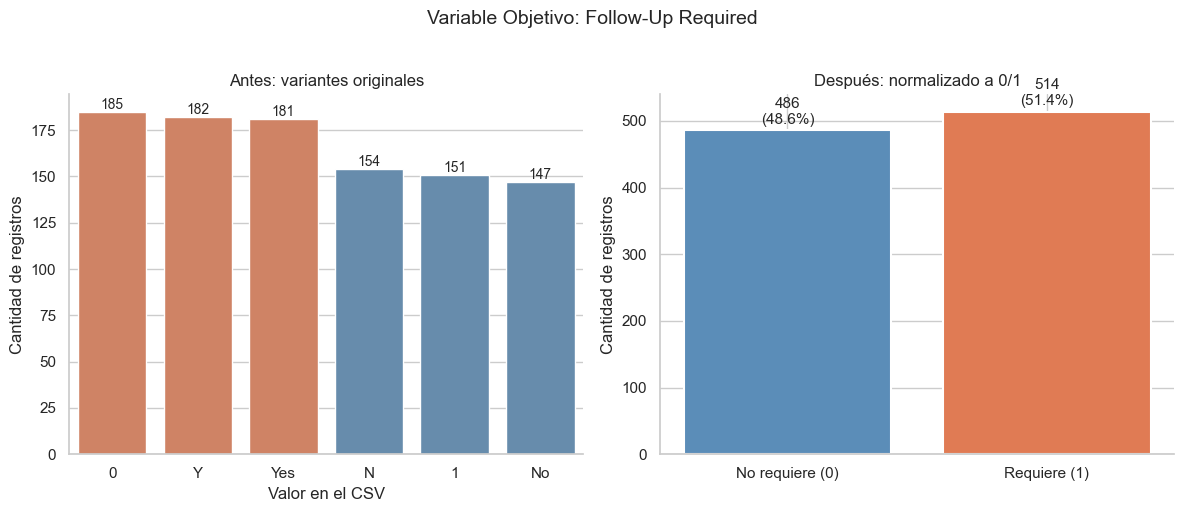

In [9]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico izquierdo: antes (con variantes)
orden_variantes = df['follow_up_required'].value_counts().index
colores_variantes = ['#E07B54', '#E07B54', '#E07B54', '#5B8DB8', '#5B8DB8', '#5B8DB8']
sns.countplot(
    data=df, x='follow_up_required',
    order=orden_variantes,
    palette=colores_variantes,
    ax=axes[0]
)
axes[0].set_title('Antes: variantes originales', fontsize=12)
axes[0].set_xlabel('Valor en el CSV')
axes[0].set_ylabel('Cantidad de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Gráfico derecho: después (binario)
conteos = df['follow_up_bin'].value_counts().sort_index()
bars = axes[1].bar(
    ['No requiere (0)', 'Requiere (1)'],
    conteos.values,
    color=['#5B8DB8', '#E07B54'],
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Después: normalizado a 0/1', fontsize=12)
axes[1].set_ylabel('Cantidad de registros')
total = conteos.sum()
for bar, val in zip(bars, conteos.values):
    pct = 100 * val / total
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

plt.suptitle('Variable Objetivo: Follow-Up Required', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo:** La variable objetivo está prácticamente **balanceada** (~51% necesita seguimiento
vs ~49% no). Esto es favorable para el modelado: no necesitaremos técnicas de balanceo
de clases como SMOTE o class_weight.


## 5. Análisis de `gender`

### Problema detectado
La columna tiene **8 representaciones distintas** más valores nulos.


In [10]:
print("Variantes en gender:")
print(df['gender'].value_counts(dropna=False))


Variantes en gender:
gender
0         129
1         128
Male      123
Female    120
F         116
female    112
male      112
M         110
NaN        50
Name: count, dtype: int64


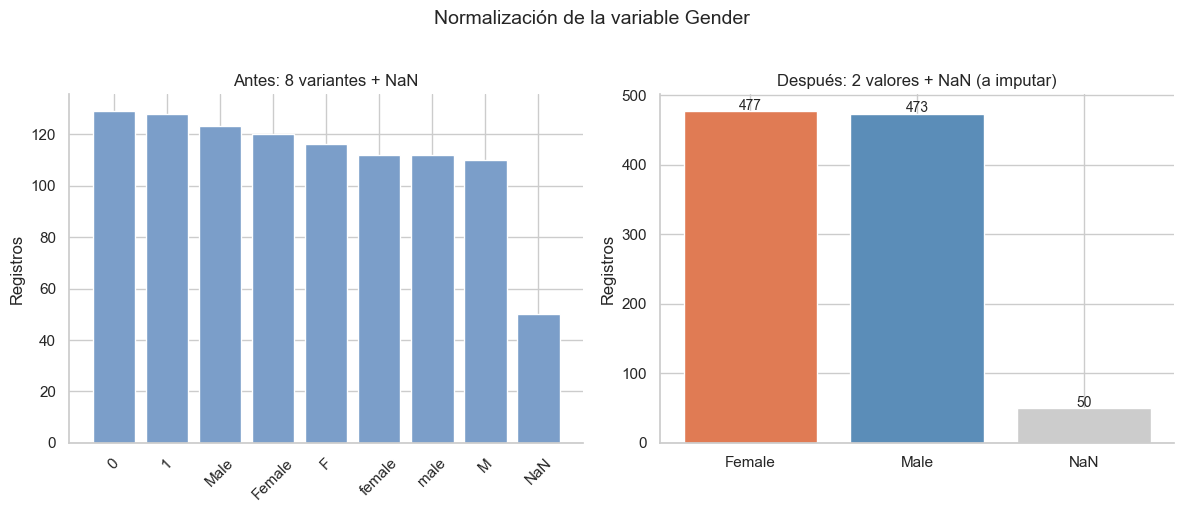


Nulos después de normalizar: 50 (serán imputados con moda)


In [11]:
# Normalizar para visualización
GENDER_MAP = {
    'male': 'Male', 'm': 'Male', '1': 'Male',
    'female': 'Female', 'f': 'Female', '0': 'Female'
}
df['gender_norm'] = df['gender'].str.strip().str.lower().map(GENDER_MAP)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
variantes = df['gender'].value_counts(dropna=False)
labels_antes = [str(v) if str(v) != 'nan' else 'NaN' for v in variantes.index]
axes[0].bar(labels_antes, variantes.values, color='#7B9EC9', edgecolor='white')
axes[0].set_title('Antes: 8 variantes + NaN', fontsize=12)
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=45)

# Después
norm_counts = df['gender_norm'].value_counts(dropna=False)
labels_despues = [str(v) if str(v) != 'nan' else 'NaN' for v in norm_counts.index]
colors_d = ['#E07B54' if l == 'Female' else '#5B8DB8' if l == 'Male' else '#CCCCCC' for l in labels_despues]
axes[1].bar(labels_despues, norm_counts.values, color=colors_d, edgecolor='white')
axes[1].set_title('Después: 2 valores + NaN (a imputar)', fontsize=12)
axes[1].set_ylabel('Registros')
for i, (label, val) in enumerate(zip(labels_despues, norm_counts.values)):
    axes[1].text(i, val + 2, str(val), ha='center', fontsize=10)

plt.suptitle('Normalización de la variable Gender', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'gender_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nNulos después de normalizar: {df['gender_norm'].isna().sum()} (serán imputados con moda)")


## 6. Análisis de `billing_amount`

### Problema detectado
La columna es de tipo texto (`object`) y contiene **4 símbolos de moneda distintos**
mezclados: `£`, `€`, `$`, `Rs`. Además tiene 50 valores nulos.


In [12]:
print("Muestra de valores en billing_amount:")
print(df['billing_amount'].dropna().head(12).tolist())
print(f"\nNulos: {df['billing_amount'].isna().sum()}")

# Contar símbolos presentes
import re
simbolos = df['billing_amount'].dropna().str.extract(r'([^\d.,]+)')[0].value_counts()
print("\nSímbolos encontrados:")
print(simbolos)


Muestra de valores en billing_amount:
['£425.8', '€344.26', '€203.34', 'Rs85.76', '$84.44', '€99.0', 'Rs374.63', '$452.37', '€494.97', '£91.91', '$82.88', 'Rs277.14']

Nulos: 50

Símbolos encontrados:
0
Rs    252
$     241
€     237
£     220
Name: count, dtype: int64


Estadísticas después de limpiar:
count    950.00
mean     276.12
std      130.12
min       51.38
25%      162.95
50%      269.84
75%      389.23
max      499.75
Name: billing_clean, dtype: float64


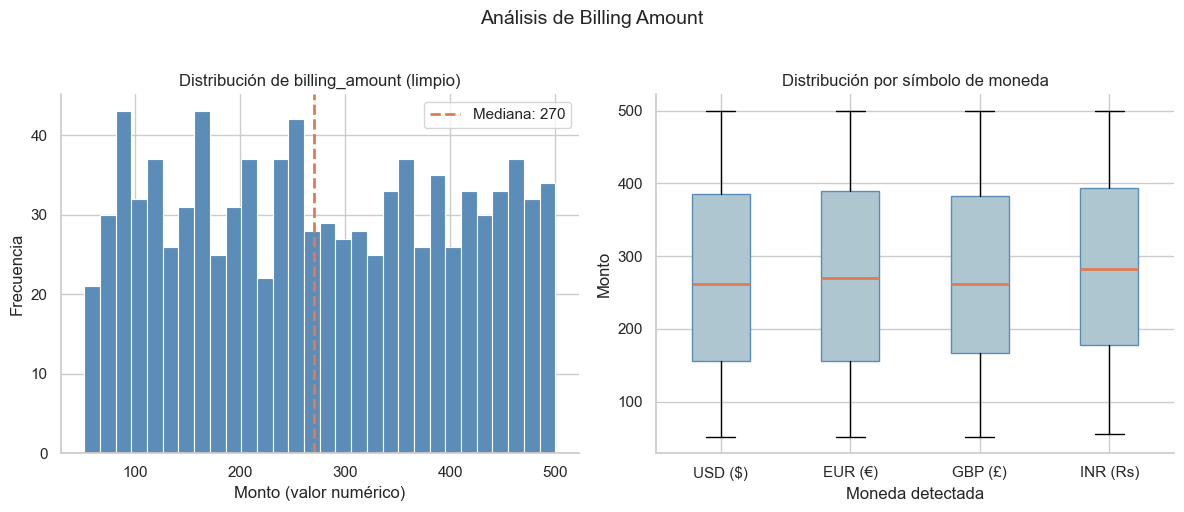


 Decisión de negocio: se descarta el símbolo. Los montos se tratan como comparables.


In [14]:
# Limpiar el monto
df['billing_clean'] = (
    df['billing_amount']
    .astype(str)
    .str.extract(r'([\d.]+)')[0]
    .astype(float)
)

print("Estadísticas después de limpiar:")
print(df['billing_clean'].describe().round(2))

# Boxplot antes (texto no graficable) vs distribución limpia
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma del monto limpio
axes[0].hist(df['billing_clean'].dropna(), bins=30, color='#5B8DB8',
             edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribución de billing_amount (limpio)', fontsize=12)
axes[0].set_xlabel('Monto (valor numérico)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['billing_clean'].median(), color='#E07B54', linewidth=2,
                linestyle='--', label=f"Mediana: {df['billing_clean'].median():.0f}")
axes[0].legend()

# Boxplot por símbolo de moneda
df['currency'] = df['billing_amount'].dropna().str.extract(r'([^\d.,]+)')[0]
df_currency = df.dropna(subset=['billing_clean', 'currency'])
currency_groups = [df_currency[df_currency['currency'] == c]['billing_clean'].values
                   for c in ['$', '€', '£', 'Rs']]
axes[1].boxplot(currency_groups, labels=['USD ($)', 'EUR (€)', 'GBP (£)', 'INR (Rs)'],
                patch_artist=True,
                boxprops=dict(facecolor='#AEC6CF', color='#5B8DB8'),
                medianprops=dict(color='#E07B54', linewidth=2))
axes[1].set_title('Distribución por símbolo de moneda', fontsize=12)
axes[1].set_ylabel('Monto')
axes[1].set_xlabel('Moneda detectada')

plt.suptitle('Análisis de Billing Amount', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'billing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Decisión de negocio: se descarta el símbolo. Los montos se tratan como comparables.")


## 7. Análisis de Fechas y Feature Engineering

### Problema detectado
Ambas columnas de fecha usan **4 formatos distintos** en el mismo campo:
`2026/02/26`, `05/23/2025`, `30-Nov-2025`, `May 18, 25`

### Solución: Feature Engineering
En lugar de intentar usar las fechas como texto, extraemos información útil:
- `waiting_days`: días entre la reserva y la cita
- `appointment_dow`: día de la semana de la cita (0=Lunes, 6=Domingo)


In [15]:
# Parsear con format='mixed' (pandas 2.x)
appt_dates    = pd.to_datetime(df['appointment_date'], format='mixed', errors='coerce')
booking_dates = pd.to_datetime(df['booking_date'],     format='mixed', errors='coerce')

df['waiting_days']    = (appt_dates - booking_dates).dt.days
df['appointment_dow'] = appt_dates.dt.dayofweek

print("Estadísticas de waiting_days:")
print(df['waiting_days'].describe().round(1))
print(f"\nValores negativos: {(df['waiting_days'] < 0).sum()} (citas antes de la reserva - error)")
print(f"Nulos en waiting_days: {df['waiting_days'].isna().sum()}")
print(f"\nDistribución día de la semana:")
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
dow_counts = df['appointment_dow'].value_counts().sort_index()
for i, c in enumerate(dow_counts):
    print(f"  {dias[i]}: {c}")


Estadísticas de waiting_days:
count    1000.0
mean      274.6
std       170.5
min         2.0
25%       130.8
50%       258.5
75%       395.2
max       728.0
Name: waiting_days, dtype: float64

Valores negativos: 0 (citas antes de la reserva - error)
Nulos en waiting_days: 0

Distribución día de la semana:
  Lunes: 138
  Martes: 140
  Miércoles: 154
  Jueves: 146
  Viernes: 141
  Sábado: 126
  Domingo: 155


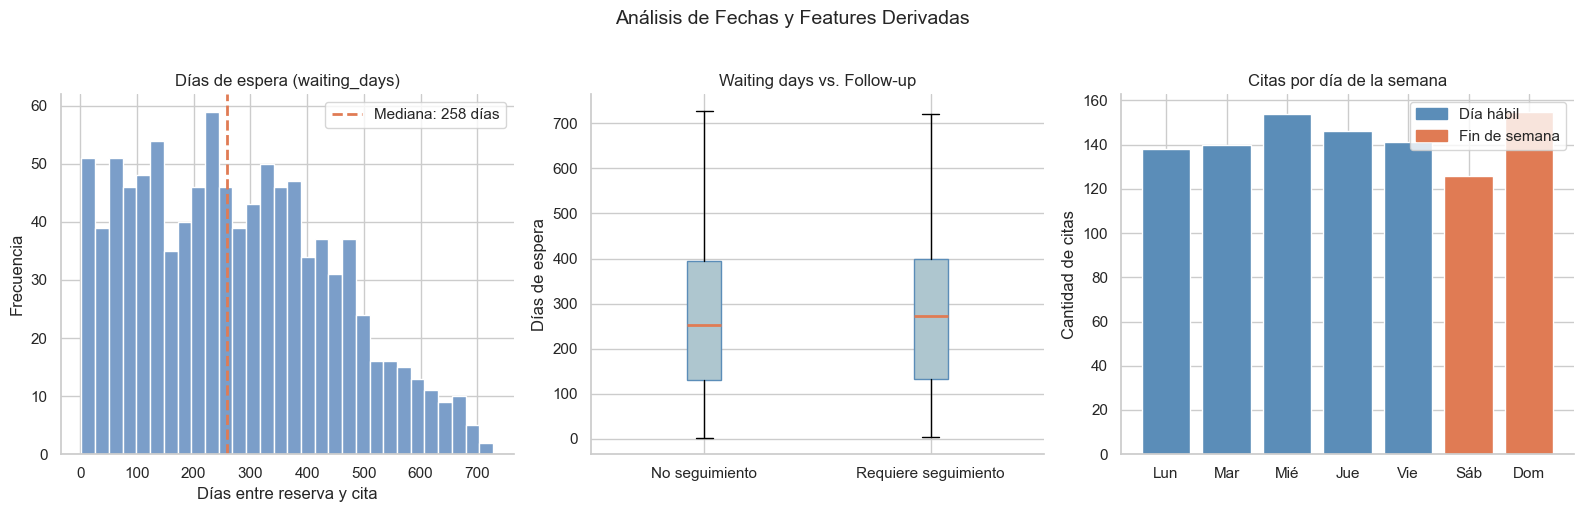

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histograma de waiting_days
axes[0].hist(df['waiting_days'].dropna(), bins=30, color='#7B9EC9', edgecolor='white')
axes[0].axvline(df['waiting_days'].median(), color='#E07B54', linewidth=2,
                linestyle='--', label=f"Mediana: {df['waiting_days'].median():.0f} días")
axes[0].set_title('Días de espera (waiting_days)', fontsize=12)
axes[0].set_xlabel('Días entre reserva y cita')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. waiting_days por necesidad de seguimiento
grupos = [
    df[df['follow_up_bin'] == 0]['waiting_days'].dropna(),
    df[df['follow_up_bin'] == 1]['waiting_days'].dropna()
]
bp = axes[1].boxplot(grupos, labels=['No seguimiento', 'Requiere seguimiento'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#AEC6CF', color='#5B8DB8'),
                     medianprops=dict(color='#E07B54', linewidth=2))
axes[1].set_title('Waiting days vs. Follow-up', fontsize=12)
axes[1].set_ylabel('Días de espera')

# 3. Citas por día de semana
dias_cortos = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dow_vals = df['appointment_dow'].value_counts().sort_index()
colors_dow = ['#E07B54' if d >= 5 else '#5B8DB8' for d in range(7)]
axes[2].bar(dias_cortos, dow_vals.values, color=colors_dow, edgecolor='white')
axes[2].set_title('Citas por día de la semana', fontsize=12)
axes[2].set_ylabel('Cantidad de citas')
weekend_patch = mpatches.Patch(color='#E07B54', label='Fin de semana')
week_patch    = mpatches.Patch(color='#5B8DB8', label='Día hábil')
axes[2].legend(handles=[week_patch, weekend_patch])

plt.suptitle('Análisis de Fechas y Features Derivadas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'date_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Distribuciones Numéricas por Variable Objetivo

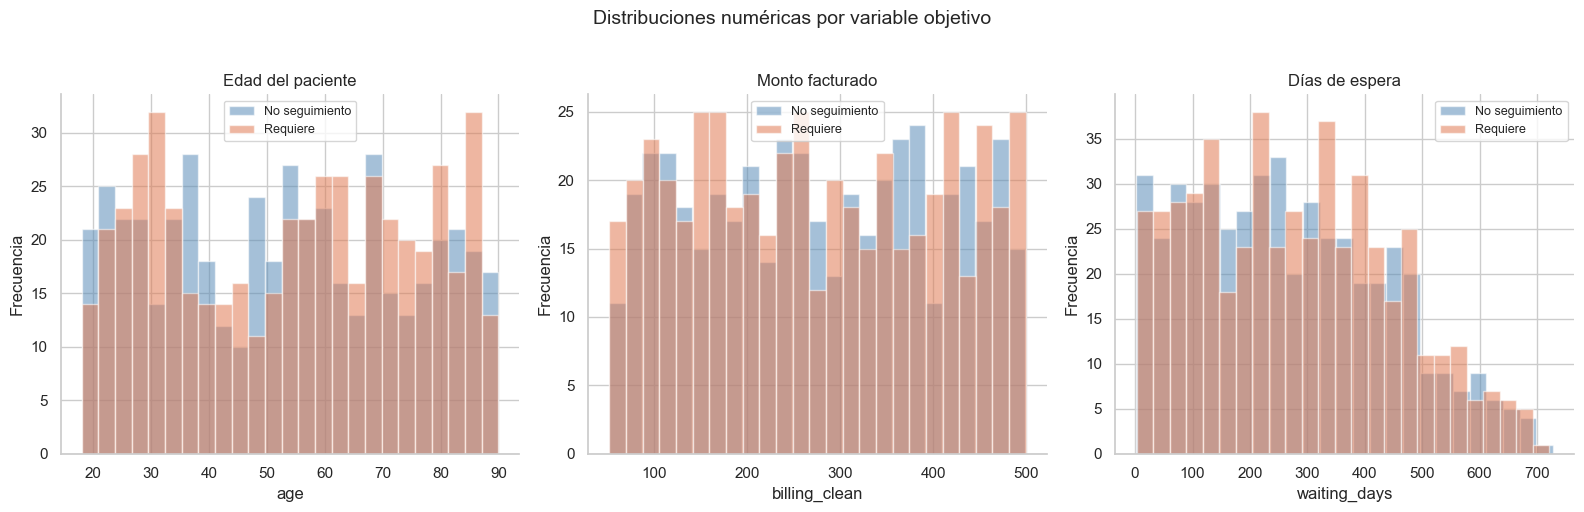

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

numeric_vars = [
    ('age',          'Edad del paciente'),
    ('billing_clean','Monto facturado'),
    ('waiting_days', 'Días de espera'),
]

for ax, (col, label) in zip(axes, numeric_vars):
    for val, color, nombre in [(0, '#5B8DB8', 'No seguimiento'), (1, '#E07B54', 'Requiere')]:
        subset = df[df['follow_up_bin'] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.55, color=color, label=nombre, edgecolor='white')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribuciones numéricas por variable objetivo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Detección y Tratamiento de Outliers

Usamos el método IQR (Rango Intercuartílico):
- Límite inferior = Q1 − 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

Cualquier valor fuera de esos límites es un outlier. En lugar de eliminar la fila
(perdemos un paciente real), aplicamos **Capping (Winsorización)**: reemplazamos
el outlier por el límite correspondiente.


age: 0 outliers | Límites: [-21.5, 126.5]
billing_clean: 0 outliers | Límites: [-176.5, 728.6]
waiting_days: 0 outliers | Límites: [-266.0, 792.0]


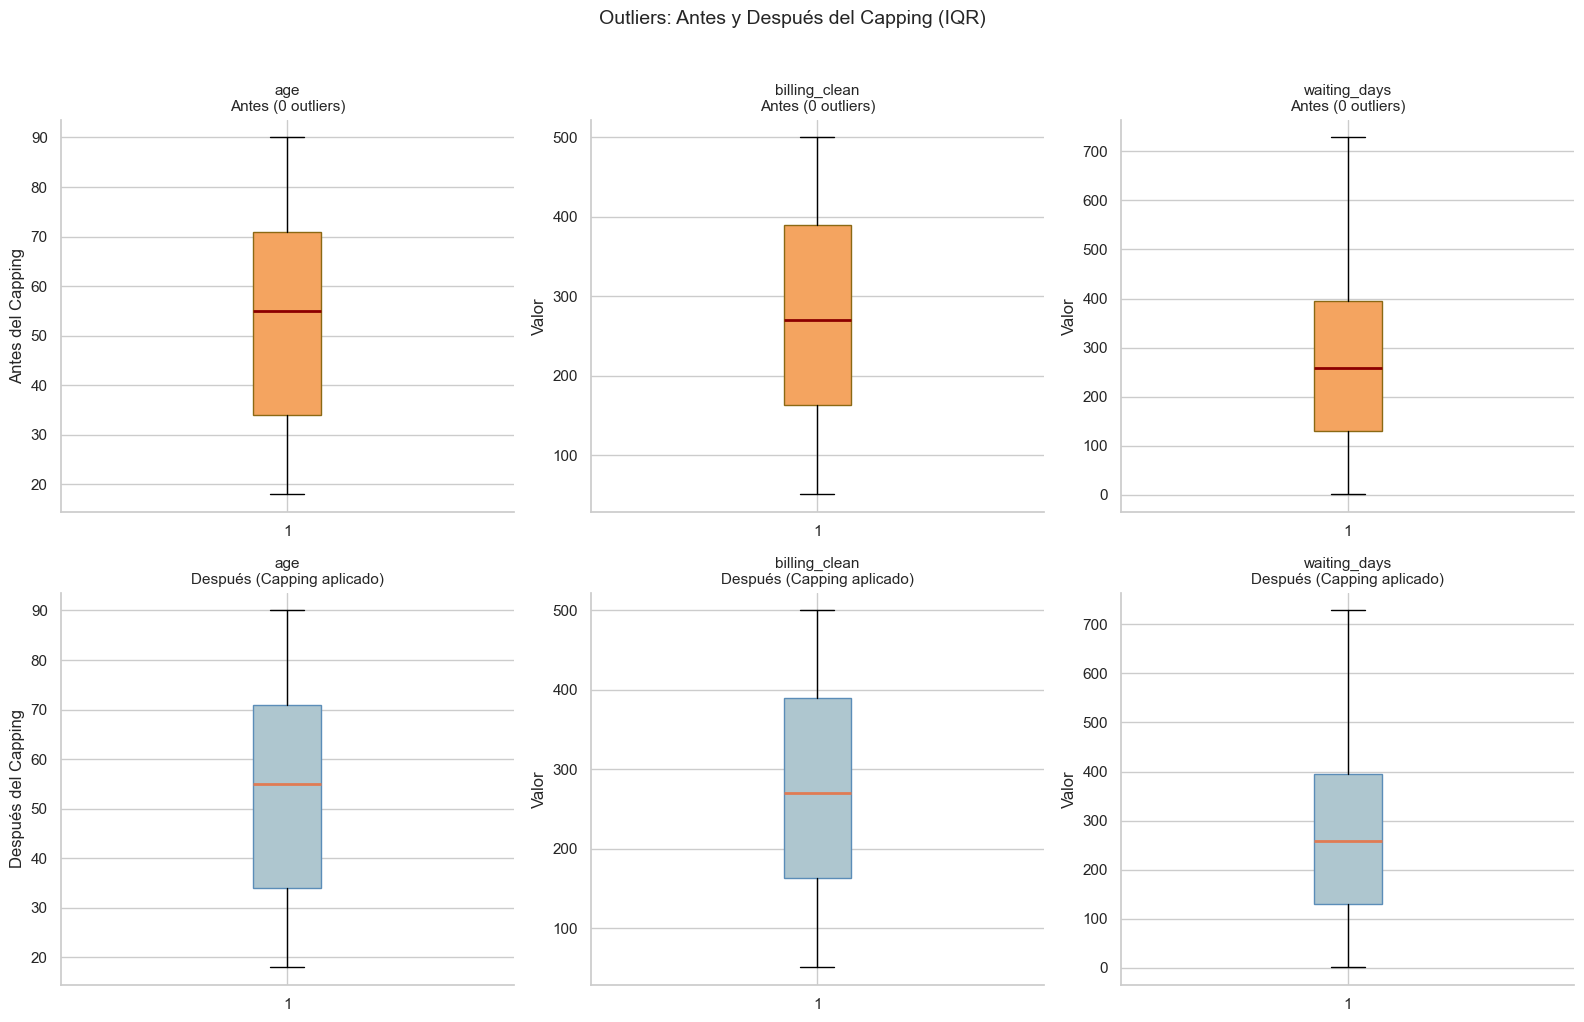

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
numeric_cols = ['age', 'billing_clean', 'waiting_days']

for i, col in enumerate(numeric_cols):
    serie = df[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    serie_capped  = serie.clip(lower, upper)
    n_outliers = ((serie < lower) | (serie > upper)).sum()

    # Antes
    axes[0, i].boxplot(serie, patch_artist=True,
                       boxprops=dict(facecolor='#F4A460', color='#8B6914'),
                       medianprops=dict(color='#8B0000', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='#E07B54',
                                       markersize=4, alpha=0.6))
    axes[0, i].set_title(f'{col}\nAntes ({n_outliers} outliers)', fontsize=11)
    axes[0, i].set_ylabel('Valor')

    # Después
    axes[1, i].boxplot(serie_capped, patch_artist=True,
                       boxprops=dict(facecolor='#AEC6CF', color='#5B8DB8'),
                       medianprops=dict(color='#E07B54', linewidth=2))
    axes[1, i].set_title(f'{col}\nDespués (Capping aplicado)', fontsize=11)
    axes[1, i].set_ylabel('Valor')

    print(f"{col}: {n_outliers} outliers | Límites: [{lower:.1f}, {upper:.1f}]")

axes[0, 0].set_ylabel('Antes del Capping', fontsize=12)
axes[1, 0].set_ylabel('Después del Capping', fontsize=12)
plt.suptitle('Outliers: Antes y Después del Capping (IQR)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'outliers_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Análisis de Variables Categóricas

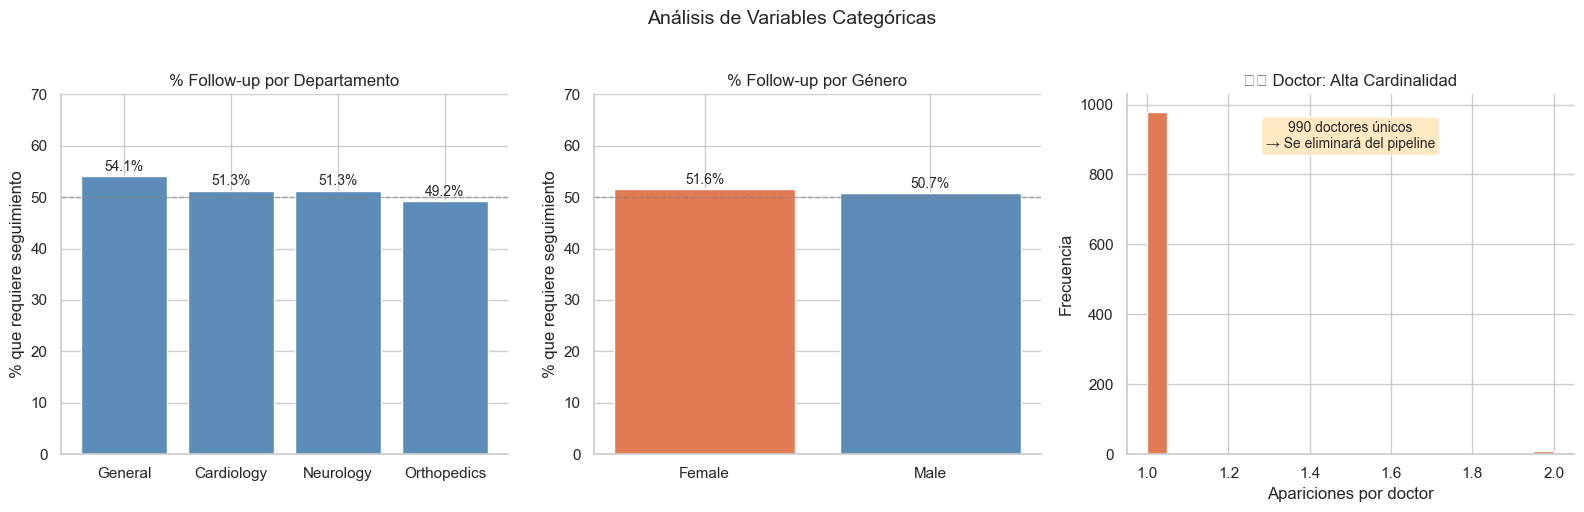

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Department
dept_follow = df.groupby('department')['follow_up_bin'].mean().sort_values(ascending=False)
bars = axes[0].bar(dept_follow.index, dept_follow.values * 100,
                   color='#5B8DB8', edgecolor='white')
axes[0].set_title('% Follow-up por Departamento', fontsize=12)
axes[0].set_ylabel('% que requiere seguimiento')
axes[0].set_ylim(0, 70)
axes[0].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars, dept_follow.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10)

# Gender vs follow_up
gen_follow = df.groupby('gender_norm')['follow_up_bin'].mean().dropna()
bars2 = axes[1].bar(gen_follow.index, gen_follow.values * 100,
                    color=['#E07B54', '#5B8DB8'], edgecolor='white')
axes[1].set_title('% Follow-up por Género', fontsize=12)
axes[1].set_ylabel('% que requiere seguimiento')
axes[1].set_ylim(0, 70)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars2, gen_follow.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10)

# Doctor: alerta de alta cardinalidad
doc_counts = df['doctor'].value_counts()
axes[2].hist(doc_counts.values, bins=20, color='#E07B54', edgecolor='white')
axes[2].set_title('⚠️ Doctor: Alta Cardinalidad', fontsize=12)
axes[2].set_xlabel('Apariciones por doctor')
axes[2].set_ylabel('Frecuencia')
axes[2].text(0.5, 0.85, f'{df["doctor"].nunique()} doctores únicos\n→ Se eliminará del pipeline',
             transform=axes[2].transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='#FFE4B5', alpha=0.8))

plt.suptitle('Análisis de Variables Categóricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo crítico:** La columna `doctor` tiene **990 valores únicos** para 1000 filas.
Aplicar OneHotEncoding generaría ~990 columnas nuevas, lo que haría el modelo inviable
(maldición de la dimensionalidad). **Decisión:** se eliminará del pipeline junto con `patient_name`.


## 11. Matriz de Correlación

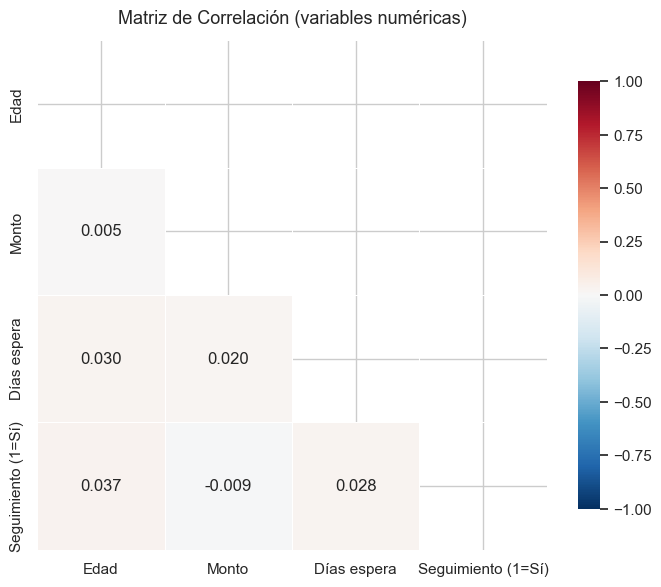


Las correlaciones bajas entre predictores indican poca multicolinealidad → bueno para el modelo.


In [22]:
# Preparar datos numéricos limpios para correlación
df_corr = df[['age', 'billing_clean', 'waiting_days', 'follow_up_bin']].copy()
df_corr.columns = ['Edad', 'Monto', 'Días espera', 'Seguimiento (1=Sí)']

matriz = df_corr.corr()

mask = np.triu(np.ones_like(matriz, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    matriz,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación (variables numéricas)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nLas correlaciones bajas entre predictores indican poca multicolinealidad → bueno para el modelo.")


## 12. Optimización de Memoria (Downcasting)

In [21]:
from src.optimization import optimize_memory_usage, process_large_file_in_chunks

print("=== Procesamiento por bloques (simulación gran escala) ===")
total = process_large_file_in_chunks(str(RAW_CSV), chunk_size=250)
print(f"Total procesado: {total} filas\n")

print("=== Downcasting de tipos de datos ===")
df_numeric = df[['age', 'billing_clean', 'waiting_days', 'follow_up_bin']].dropna()
df_optimized = optimize_memory_usage(df_numeric)


INFO: Procesando c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\data\raw\messy_clinic_appointments.csv en bloques de 250 filas...
INFO:   Bloque 1: 250 filas procesadas.
INFO:   Bloque 2: 250 filas procesadas.
INFO:   Bloque 3: 250 filas procesadas.
INFO:   Bloque 4: 250 filas procesadas.
INFO: Procesamiento completado. Total de filas: 1000
INFO: Iniciando optimización de memoria (downcasting)...
INFO: Memoria inicial: 0.0362 MB
INFO: Memoria optimizada: 0.0145 MB
INFO: Reducción lograda:  60.0%


=== Procesamiento por bloques (simulación gran escala) ===
Total procesado: 1000 filas

=== Downcasting de tipos de datos ===


## 13. Resumen de Decisiones de Transformación

Esta tabla resume todos los problemas encontrados y las decisiones que tomamos,
las cuales se implementan en `src/transformers.py` y `src/pipeline.py`.

| Columna | Problema detectado | Decisión de transformación |
|---|---|---|
| `patient_name` | Sin valor predictivo (identidad) | Eliminar (`DropColumnsTransformer`) |
| `patient_id` | 899 duplicados — legítimos (un paciente, varias citas) | Mantener sin cambios |
| `gender` | 8 variantes + 50 nulos | `GenderNormalizerTransformer` → imputar moda |
| `age` | Limpio, rango 18-90 | `OutlierCapper` + `StandardScaler` |
| `appointment_date` | 4 formatos de texto distintos | `DateFeatureTransformer` → `waiting_days`, `appointment_dow` |
| `booking_date` | 4 formatos de texto distintos | Usada para calcular `waiting_days`, luego eliminar |
| `doctor` | 990 valores únicos (alta cardinalidad) | Eliminar (`DropColumnsTransformer`) |
| `department` | 4 valores, limpio | `OneHotEncoder` |
| `billing_amount` | Texto con símbolo de moneda + 50 nulos | `BillingCleanerTransformer` → imputar mediana |
| `follow_up_required` | 6 variantes → binario | Normalizar a `1/0` antes del pipeline |

**Variable objetivo:** `follow_up_required` normalizada a `1/0` — balanceada (~51/49%).

**Features finales para el modelo:**
- Numéricas: `age`, `billing_amount`, `waiting_days`
- Categóricas: `gender`, `department`
- Feature nueva: `appointment_dow` (día de la semana)
